# Assignment 2

## Imports

In [1]:
import scipy.io
import numpy as np
import pandas as pd
import wandb
import tqdm
import torch
import torchvision.io as io
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
import torchvision.models as models
import time
import matplotlib.pyplot as plt

In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jsonschema/_format.py", line 304, in <module>
    import rfc3987
ModuleNotFoundError: No module named 'rfc3987'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_4828/2366315092.py", line 1, in <cell line: 0>
    wandb.login()
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_login.py", line 86, in login
    global_settings = wandb_setup.singleton().settings
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_setup.py", line 292, in settings
    self._load_settings(
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_setup.py", line 234, in _load_settings
    self._settings.updat

TypeError: object of type 'NoneType' has no len()

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data

In [ ]:
ids = scipy.io.loadmat('data/setid.mat')
# -1 because of 1 as starting index
trnid = ids['trnid'].flatten() - 1
valid = ids['valid'].flatten() - 1
tstid = ids['tstid'].flatten() - 1

In [ ]:
path = 'data/102flowers/jpg/image_'
resize = transforms.Resize((224, 224))

X = torch.stack([resize(io.read_image(path + str(i).zfill(5) + '.jpg')) for i in range(1, 8190)])
X = X.float() / 255.0 # normalization

In [ ]:
X_train = X[trnid]
X_val = X[valid]
X_test = X[tstid]

In [ ]:
y = torch.tensor(scipy.io.loadmat('data/imagelabels.mat')['labels'], dtype=torch.long).flatten() - 1
y_train = y[trnid]
y_val = y[valid]
y_test = y[tstid]

In [12]:
import torchvision

# Define the transformations for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224 as expected by VGG models
    transforms.ToTensor(),         # Convert PIL Image to PyTorch Tensor (scales to [0.0, 1.0])
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

data_train = torchvision.datasets.Flowers102('/data', download=True, transform=transform)
data_val = torchvision.datasets.Flowers102('/data', download=True, split='val', transform=transform)


In [5]:
data_val

Dataset Flowers102
    Number of datapoints: 1020
    Root location: /data
    split=val

In [6]:
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

NameError: name 'X_train' is not defined

In [7]:
train_loader = DataLoader(data_train, batch_size=32, shuffle=True)
val_loader = DataLoader(data_val, batch_size=32)

In [ ]:
n_train = len(train_ds)
n_val = len(val_ds)
train_ds_10 = torch.utils.data.Subset(train_ds, torch.randperm(n_train)[:n_train // 10])
val_ds_10 = torch.utils.data.Subset(val_ds, torch.arange(n_val))

train_loader_10 = DataLoader(train_ds_10, batch_size=32, shuffle=True)
val_loader_10 = DataLoader(val_ds_10, batch_size=32)

## Task 0

In [8]:
project = 'ADM-List2-T0'

lr = 1e-4
weight_decay = 1e-4
epochs = 50

config = {
    'epochs': epochs,
    'lr': lr,
    'weight_decay': weight_decay,
}

In [ ]:
class ExampleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(ExampleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Fully connected layers
        self.c = 56*56*16
        self.fc1 = nn.Linear(self.c, 1024) # Flatten (512 * 7 * 7) features
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, self.c) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # logits for all classes
        return x

In [16]:
model = ExampleCNN().to(device)
optimizer = Adam(lr=lr, weight_decay=weight_decay, params=model.parameters())
loss = nn.CrossEntropyLoss()

NameError: name 'ExampleCNN' is not defined

In [17]:
loss = nn.CrossEntropyLoss()

In [ ]:
with wandb.init(project=project, config=config) as run:
    for epoch in tqdm.trange(epochs):
        total_train_loss = 0
        total_train_correct = 0
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()

            preds = model(X)
            running_loss = loss(preds, y)
            total_train_loss += running_loss.item()
            total_train_correct += (preds.argmax(dim=1) == y).sum().item()
            running_loss.backward()
            optimizer.step()

        total_val_loss = 0
        total_val_correct = 0
        model.eval()
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                preds = model(X)
                total_val_loss += loss(preds, y).item()
                total_val_correct += (preds.argmax(dim=1) == y).sum().item()
        wandb.log({
            'train_loss': total_train_loss / len(train_loader),
            'val_loss': total_val_loss / len(val_loader),
            'train_acc': total_train_correct / len(train_ds),
            'val_acc': total_val_correct / len(val_ds),
            'epoch': epoch
        })


100%|██████████| 50/50 [00:24<00:00,  2.06it/s]


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▁▁▂▂▂▃▃▄▄▅▅▆▆▆▇▇▇▇▇▇███████████████████
train_loss,███▇▇▆▆▅▅▅▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▄▆▆▇▇▇▇█▇▇▇▇▇▇▇█▇█▇▇▇▇▇▆▇▇▇▇█▇▇▇▇▆▇▇
val_loss,█▇▆▅▄▂▂▂▁▁▁▁▁▁▁▂▂▂▃▃▃▃▄▃▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆
epoch,49
train_acc,0.99412
train_loss,0.05355
val_acc,0.17745
val_loss,4.25595


### 10% of samples

In [ ]:
project_10 = 'ADM-List2-T0-10pct'

model_10 = ExampleCNN().to(device)
optimizer_10 = Adam(lr=lr, weight_decay=weight_decay, params=model_10.parameters())

with wandb.init(project=project_10, config=config) as run:
    for epoch in tqdm.trange(epochs):
        total_train_loss = 0
        total_train_correct = 0
        model_10.train()
        for X_batch, y_batch in train_loader_10:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer_10.zero_grad()

            preds = model_10(X_batch)
            running_loss = loss(preds, y_batch)
            total_train_loss += running_loss.item()
            total_train_correct += (preds.argmax(dim=1) == y_batch).sum().item()
            running_loss.backward()
            optimizer_10.step()

        total_val_loss = 0
        total_val_correct = 0
        model_10.eval()
        with torch.no_grad():
            for X_batch, y_batch in val_loader_10:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model_10(X_batch)
                total_val_loss += loss(preds, y_batch).item()
                total_val_correct += (preds.argmax(dim=1) == y_batch).sum().item()

        wandb.log({
            'train_loss': total_train_loss / len(train_loader_10),
            'val_loss': total_val_loss / len(val_loader_10),
            'train_acc': total_train_correct / len(train_ds_10),
            'val_acc': total_val_correct / len(val_ds_10),
            'epoch': epoch
        })


100%|██████████| 50/50 [00:06<00:00,  7.30it/s]


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▁▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▇▇▇▇▇▇▇███████████
train_loss,███▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▁▁▂▂▂▄▄▄▅▅▄▄▄▆▅▅▅█▇▇▇▇▇▆▆▆██▇▇▇▇██▇
val_loss,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇██
epoch,49
train_acc,1
train_loss,0.15686
val_acc,0.05294
val_loss,7.87826


Full dataset has: 15% acc
10% dataset has: 5% acc

50 epochs: 30s(full dataset) vs 10s(10% dataset)

### VGG-13 from scratch

In [ ]:
vgg13 = models.vgg13(weights=None, num_classes=102)
vgg13 = vgg13.to(device)

optimizer_vgg = Adam(lr=1e-4, params=vgg13.parameters())
project_vgg = 'ADM-List2-T0-VGG13-scratch'

start_time = time.time()
with wandb.init(project=project_vgg, config=config) as run:
    for epoch in tqdm.trange(epochs):
        if time.time() - start_time > 20 * 60:
            print("Time limit exceeded, stopping training.")
            break

        total_train_loss = 0
        total_train_correct = 0
        vgg13.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer_vgg.zero_grad()

            preds = vgg13(X_batch)
            running_loss = loss(preds, y_batch)
            total_train_loss += running_loss.item()
            total_train_correct += (preds.argmax(dim=1) == y_batch).sum().item()
            running_loss.backward()
            optimizer_vgg.step()

        total_val_loss = 0
        total_val_correct = 0
        vgg13.eval()
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = vgg13(X_batch)
                total_val_loss += loss(preds, y_batch).item()
                total_val_correct += (preds.argmax(dim=1) == y_batch).sum().item()

        wandb.log({
            'train_loss': total_train_loss / len(train_loader),
            'val_loss': total_val_loss / len(val_loader),
            'train_acc': total_train_correct / len(train_ds),
            'val_acc': total_val_correct / len(val_ds),
            'epoch': epoch
        })


100%|██████████| 50/50 [04:05<00:00,  4.92s/it]


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▁▁▁▁▁▁▂▂▂▄▅▆▆██████████████████████████
train_loss,█████▇▇▇▆▆▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▂▄▄▄▅▆▇▇▆█▇▇▇█▇██▇█▇▇▇██▇█▇▇▇▇▇▇▇▇▇▇
val_loss,▂▂▂▂▂▁▁▁▁▁▂▃▄▅▆▆█▇▃▆▆▆▅▆▆▇▅▇▇▇▆█▇▅▅▇▇▆▆▇
epoch,49
train_acc,0.98824
train_loss,0.04043
val_acc,0.16078
val_loss,8.82505


It took 4m 17s on gpu on 50 epochs. 15% Accuracy.

The VGG-13 model was trained on the ImageNet dataset, which consists of over 14 million images and 1000 classes. Training from scratch on ImageNet takes weeks on multiple GPUs.


Conclusion: Transfer learning is crucial when we don't have large datasets or time or resources.

## Task 1

In [ ]:
vgg13_pt = models.vgg13(weights=models.VGG13_Weights.IMAGENET1K_V1)

for param in vgg13_pt.features.parameters():
    param.requires_grad = False

vgg13_pt.classifier[6] = nn.Linear(4096, 102)
vgg13_pt = vgg13_pt.to(device)

optimizer_pt = Adam(lr=1e-4, params=vgg13_pt.classifier.parameters())
project_pt = 'ADM-List2-T1-VGG13-pretrained'

with wandb.init(project=project_pt, config=config) as run:
    for epoch in tqdm.trange(epochs):
        total_train_loss = 0
        total_train_correct = 0
        vgg13_pt.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer_pt.zero_grad()

            preds = vgg13_pt(X_batch)
            running_loss = loss(preds, y_batch)
            total_train_loss += running_loss.item()
            total_train_correct += (preds.argmax(dim=1) == y_batch).sum().item()
            running_loss.backward()
            optimizer_pt.step()

        total_val_loss = 0
        total_val_correct = 0
        vgg13_pt.eval()
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = vgg13_pt(X_batch)
                total_val_loss += loss(preds, y_batch).item()
                total_val_correct += (preds.argmax(dim=1) == y_batch).sum().item()

        wandb.log({
            'train_loss': total_train_loss / len(train_loader),
            'val_loss': total_val_loss / len(val_loader),
            'train_acc': total_train_correct / len(train_ds),
            'val_acc': total_val_correct / len(val_ds),
            'epoch': epoch
        })


100%|██████████| 50/50 [02:15<00:00,  2.71s/it]


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▄▆▇████████████████████████████████████
train_loss,█▆▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▆▇▇▇██████████████████████████████████
val_loss,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_acc,1
train_loss,0.00041
val_acc,0.75098
val_loss,0.9386


In [ ]:
num_blocks_to_freeze_list = [10, 11, 12]
results = {}

for freeze_layers in num_blocks_to_freeze_list:
    model_ft = models.vgg13(weights=models.VGG13_Weights.IMAGENET1K_V1)


    for i, param in enumerate(model_ft.features.parameters()):
        if i <= freeze_layers:
            param.requires_grad = False

    model_ft.classifier[6] = nn.Linear(4096, 102)
    model_ft = model_ft.to(device)

    opt_ft = Adam(lr=1e-4, params=filter(lambda p: p.requires_grad, model_ft.parameters()))

    time_taken = 0
    epochs_for_75 = -1
    acc_history = []
    time_history = []

    for epoch in range(epochs):
        start_ep = time.time()
        model_ft.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt_ft.zero_grad()
            preds = model_ft(X_batch)
            l = loss(preds, y_batch)
            l.backward()
            opt_ft.step()

        model_ft.eval()
        correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model_ft(X_batch)
                correct += (preds.argmax(dim=1) == y_batch).sum().item()

        ep_time = time.time() - start_ep
        time_taken += ep_time
        val_acc = correct / len(data_val)
        acc_history.append(val_acc)
        time_history.append(time_taken)

        if val_acc >= 0.75 and epochs_for_75 == -1:
            epochs_for_75 = epoch + 1

    results[freeze_layers] = {
        'acc': acc_history,
        'time': time_history,
        'epochs_75': epochs_for_75,
        'total_time': time_taken
    }

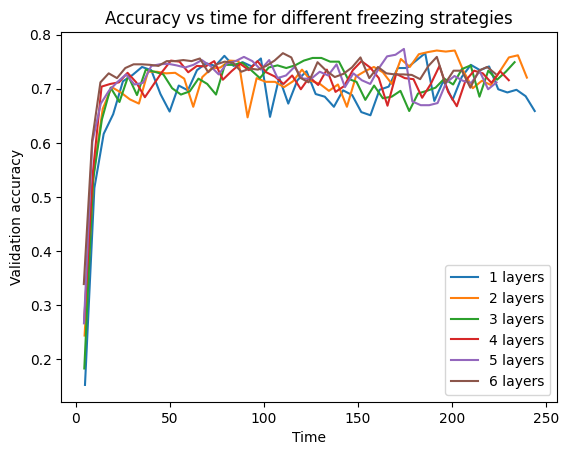

In [ ]:
for fb, res in results.items():
    plt.plot(res['time'], res['acc'], label=f'{fb} layers')
plt.xlabel('Time')
plt.ylabel('Validation accuracy')
plt.legend()
plt.title('Accuracy vs time for different freezing strategies')
plt.show()


In [ ]:
freezing_layers = list(results.keys())
epochs_75 = [results[fb]['epochs_75'] for fb in freezing_layers]
time_75 = []

for fb in freezing_layers:
    epochs_needed = results[fb]['epochs_75']
    if epochs_needed > 0:
        time_75.append(results[fb]['time'][epochs_needed - 1])
    else:
        time_75.append(0)

pd.DataFrame({
    'Frozen layers (from last)': freezing_layers,
    'Epochs to 75%': epochs_75,
    'Time to 75%': [round(t, 2) for t in time_75]
})

,Frozen layers (from last),Epochs to 75%,Time to 75%
0,1,16,79.12
1,2,17,81.83
2,3,26,121.36
3,4,11,50.69
4,5,15,67.14
5,6,11,48.48
